Dimensiones del dataset: (14561, 68)

Primeras filas:
                         Diag 01 Principal (cod+des)  \
0            A41.8 - Otras septicemias especificadas   
1               U07.1 - COVID-19, virus identificado   
2  K56.5 - Adherencias [bridas] intestinales con ...   
3  K76.8 - Otras enfermedades especificadas del h...   
4  T81.0 - Hemorragia y hematoma que complican un...   

                        Diag 02 Secundario (cod+des)  \
0     B37.6 - Endocarditis debida a candida (I39.8*)   
1              J12.8 - Neumonía debida a otros virus   
2                              R57.2 - Shock séptico   
3                              K66.1 - Hemoperitoneo   
4  Y83.2 - Operación quirúrgica con anastomosis, ...   

                        Diag 03 Secundario (cod+des)  \
0  I39.8 - Endocarditis, válvula no especificada,...   
1                                     R06.0 - Disnea   
2                        R57.1 - Choque hipovolémico   
3        N18.5 - Enfermedad renal crónica, estad

C:\Users\SERGIO VILLEGAS\AppData\Local\Temp\ipykernel_21584\3760828424.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_clean.groupby('Sexo')[var].describe())
C:\Users\SERGIO VILLEGAS\AppData\Local\Temp\ipykernel_21584\3760828424.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_clean.groupby('Sexo')[var].describe())
C:\Users\SERGIO VILLEGAS\AppData\Local\Temp\ipykernel_21584\3760828424.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt 

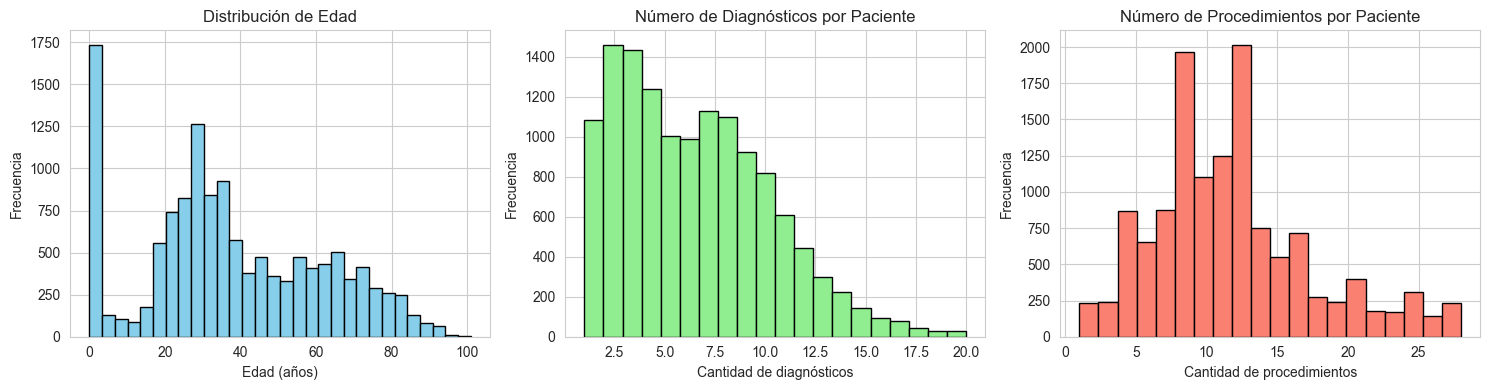

C:\Users\SERGIO VILLEGAS\AppData\Local\Temp\ipykernel_21584\3760828424.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([datos_original, df_clean[var].dropna()], labels=['Original', 'Sin outliers'])
C:\Users\SERGIO VILLEGAS\AppData\Local\Temp\ipykernel_21584\3760828424.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([datos_original, df_clean[var].dropna()], labels=['Original', 'Sin outliers'])
C:\Users\SERGIO VILLEGAS\AppData\Local\Temp\ipykernel_21584\3760828424.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([datos_original, df_clean[var].dropna()], la

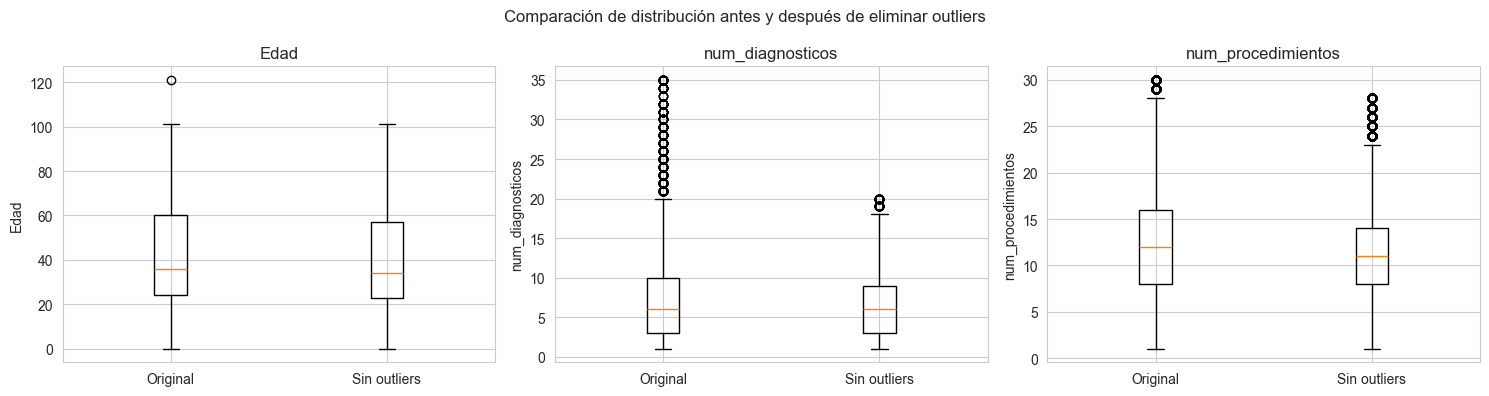

In [1]:
# ==================================================
# 1. Importación de librerías
# ==================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ==================================================
# 2. Carga del dataset
# ==================================================
# El archivo está en formato CSV con separador punto y coma
# Los valores nulos se representan como "-"
df = pd.read_csv('dataset_elpino.csv', sep=';', na_values='-', low_memory=False)

print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
print(df.head())

# ==================================================
# 3. Completitud de los datos
# ==================================================
# Porcentaje de valores no nulos por columna
completitud_columnas = df.notnull().mean() * 100
print("\n--- Completitud por columna (top 10) ---")
print(completitud_columnas.sort_values(ascending=False).head(10))

# Porcentaje de filas completamente nulas
filas_totales = df.shape[0]
filas_sin_datos = df.isnull().all(axis=1).sum()
print(f"\nFilas completamente vacías: {filas_sin_datos} ({filas_sin_datos/filas_totales*100:.2f}%)")

# Distribución de cantidad de no nulos por fila
df['num_no_nulos'] = df.notnull().sum(axis=1)
print("\nEstadísticas de cantidad de valores no nulos por fila:")
print(df['num_no_nulos'].describe())

# ==================================================
# 4. Eliminación de duplicados
# ==================================================
duplicados = df.duplicated().sum()
print(f"\nFilas duplicadas: {duplicados}")
if duplicados > 0:
    df = df.drop_duplicates()
    print("Duplicados eliminados.")

# ==================================================
# 5. Correctitud de datos y conversión de tipos
# ==================================================
# Convertir columna 'Edad en años' a numérica (puede haber valores no numéricos)
df['Edad'] = pd.to_numeric(df['Edad en años'], errors='coerce')

# Convertir columna 'Sexo (Desc)' a categórica
df['Sexo'] = df['Sexo (Desc)'].astype('category')

# Contar diagnósticos por paciente (columnas Diag 01 a Diag 35)
diag_cols = [col for col in df.columns if col.startswith('Diag')]
df['num_diagnosticos'] = df[diag_cols].notnull().sum(axis=1)

# Contar procedimientos por paciente (columnas Proced 01 a Proced 30)
proc_cols = [col for col in df.columns if col.startswith('Proced')]
df['num_procedimientos'] = df[proc_cols].notnull().sum(axis=1)

print("\n--- Correctitud de datos ---")
print(f"Edad: {df['Edad'].dtype} - valores nulos: {df['Edad'].isnull().sum()}")
print(f"Sexo: {df['Sexo'].dtype} - categorías: {df['Sexo'].cat.categories.tolist()}")
print(f"Diagnósticos: min={df['num_diagnosticos'].min()}, max={df['num_diagnosticos'].max()}")
print(f"Procedimientos: min={df['num_procedimientos'].min()}, max={df['num_procedimientos'].max()}")

# ==================================================
# 6. Detección y eliminación de outliers (Edad, num_diagnosticos, num_procedimientos)
# ==================================================
def detectar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = serie[(serie < lower) | (serie > upper)]
    return lower, upper, outliers

variables = ['Edad', 'num_diagnosticos', 'num_procedimientos']
outliers_info = {}
for var in variables:
    datos = df[var].dropna()
    lower, upper, outliers = detectar_outliers_iqr(datos)
    outliers_info[var] = {'lower': lower, 'upper': upper, 'count': len(outliers)}
    print(f"\n{var}: límite inferior={lower:.2f}, superior={upper:.2f}, outliers={len(outliers)} ({len(outliers)/len(datos)*100:.2f}%)")

# Eliminar filas con outliers en edad
df_clean = df.copy()
cond_edad = (df_clean['Edad'] >= outliers_info['Edad']['lower']) & (df_clean['Edad'] <= outliers_info['Edad']['upper'])
df_clean = df_clean[cond_edad | df_clean['Edad'].isna()]

# Eliminar outliers en número de diagnósticos
cond_diag = (df_clean['num_diagnosticos'] >= outliers_info['num_diagnosticos']['lower']) & (df_clean['num_diagnosticos'] <= outliers_info['num_diagnosticos']['upper'])
df_clean = df_clean[cond_diag]

# Eliminar outliers en número de procedimientos
cond_proc = (df_clean['num_procedimientos'] >= outliers_info['num_procedimientos']['lower']) & (df_clean['num_procedimientos'] <= outliers_info['num_procedimientos']['upper'])
df_clean = df_clean[cond_proc]

print(f"\nRegistros después de eliminar outliers: {df_clean.shape[0]} (original: {df.shape[0]})")

# ==================================================
# 7. Comparación de géneros
# ==================================================
print("\n--- Comparación por género ---")
print(df_clean['Sexo'].value_counts(dropna=False))

# Estadísticas por género
for var in ['Edad', 'num_diagnosticos', 'num_procedimientos']:
    print(f"\n{var}:")
    print(df_clean.groupby('Sexo')[var].describe())

# Prueba de diferencia de medias (ANOVA o t-test)
from scipy.stats import f_oneway
grupos = [df_clean[df_clean['Sexo'] == sexo]['Edad'].dropna() for sexo in df_clean['Sexo'].dropna().unique()]
if len(grupos) > 1:
    f_stat, p_val = f_oneway(*grupos)
    print(f"\nDiferencia de edad entre géneros: p-value = {p_val:.4f} (significativo si <0.05)")

# ==================================================
# 8. Medidas de tendencia central y dispersión
# ==================================================
print("\n--- Medidas de tendencia central y dispersión (sin outliers) ---")
for var in variables:
    datos = df_clean[var].dropna()
    print(f"\n{var}:")
    print(f"  Media: {datos.mean():.2f}")
    print(f"  Mediana: {datos.median():.2f}")
    print(f"  Moda: {datos.mode().iloc[0] if not datos.mode().empty else 'N/A'}")
    print(f"  Desviación estándar: {datos.std():.2f}")
    print(f"  Varianza: {datos.var():.2f}")
    print(f"  Rango: {datos.max() - datos.min()}")
    print(f"  Rango intercuartil: {datos.quantile(0.75) - datos.quantile(0.25):.2f}")

# ==================================================
# 9. Histogramas
# ==================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma de Edad
axes[0].hist(df_clean['Edad'].dropna(), bins=30, edgecolor='black', color='skyblue')
axes[0].set_title('Distribución de Edad')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')

# Histograma de número de diagnósticos
axes[1].hist(df_clean['num_diagnosticos'].dropna(), bins=20, edgecolor='black', color='lightgreen')
axes[1].set_title('Número de Diagnósticos por Paciente')
axes[1].set_xlabel('Cantidad de diagnósticos')
axes[1].set_ylabel('Frecuencia')

# Histograma de número de procedimientos
axes[2].hist(df_clean['num_procedimientos'].dropna(), bins=20, edgecolor='black', color='salmon')
axes[2].set_title('Número de Procedimientos por Paciente')
axes[2].set_xlabel('Cantidad de procedimientos')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# ==================================================
# 10. Boxplots para visualizar outliers (antes/después)
# ==================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, var in enumerate(variables):
    # Boxplot antes de limpieza
    datos_original = df[var].dropna()
    axes[i].boxplot([datos_original, df_clean[var].dropna()], labels=['Original', 'Sin outliers'])
    axes[i].set_title(f'{var}')
    axes[i].set_ylabel(var)

plt.suptitle('Comparación de distribución antes y después de eliminar outliers')
plt.tight_layout()
plt.show()

Dimensiones después de limpieza básica: (14416, 72)
Outliers en edad eliminados: solo valores >114 años
Rango de diagnósticos: 1 - 35
Rango de procedimientos: 1 - 30

--- Estadísticas descriptivas (con outliers) ---

Edad:
  Media: 39.80
  Mediana: 36.00
  Desv. estándar: 24.49
  Percentil 95: 80.00
  Máximo: 101

num_diagnosticos:
  Media: 7.23
  Mediana: 6.00
  Desv. estándar: 5.21
  Percentil 95: 17.00
  Máximo: 35

num_procedimientos:
  Media: 13.33
  Mediana: 12.00
  Desv. estándar: 7.31
  Percentil 95: 30.00
  Máximo: 30

--- Comparación por género (con outliers) ---
Sexo
Mujer     9541
Hombre    4875
Name: count, dtype: int64

Edad por género:
         count       mean        std  min   25%   50%   75%    max
Sexo                                                              
Hombre  4875.0  44.221949  27.872842  0.0  21.0  52.0  66.0   97.0
Mujer   9541.0  37.546588  22.229041  0.0  24.0  33.0  52.0  101.0

num_diagnosticos por género:
         count      mean       std  min  25

C:\Users\SERGIO VILLEGAS\AppData\Local\Temp\ipykernel_21584\104624541.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Sexo')[var].describe())
C:\Users\SERGIO VILLEGAS\AppData\Local\Temp\ipykernel_21584\104624541.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Sexo')[var].describe())
C:\Users\SERGIO VILLEGAS\AppData\Local\Temp\ipykernel_21584\104624541.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default

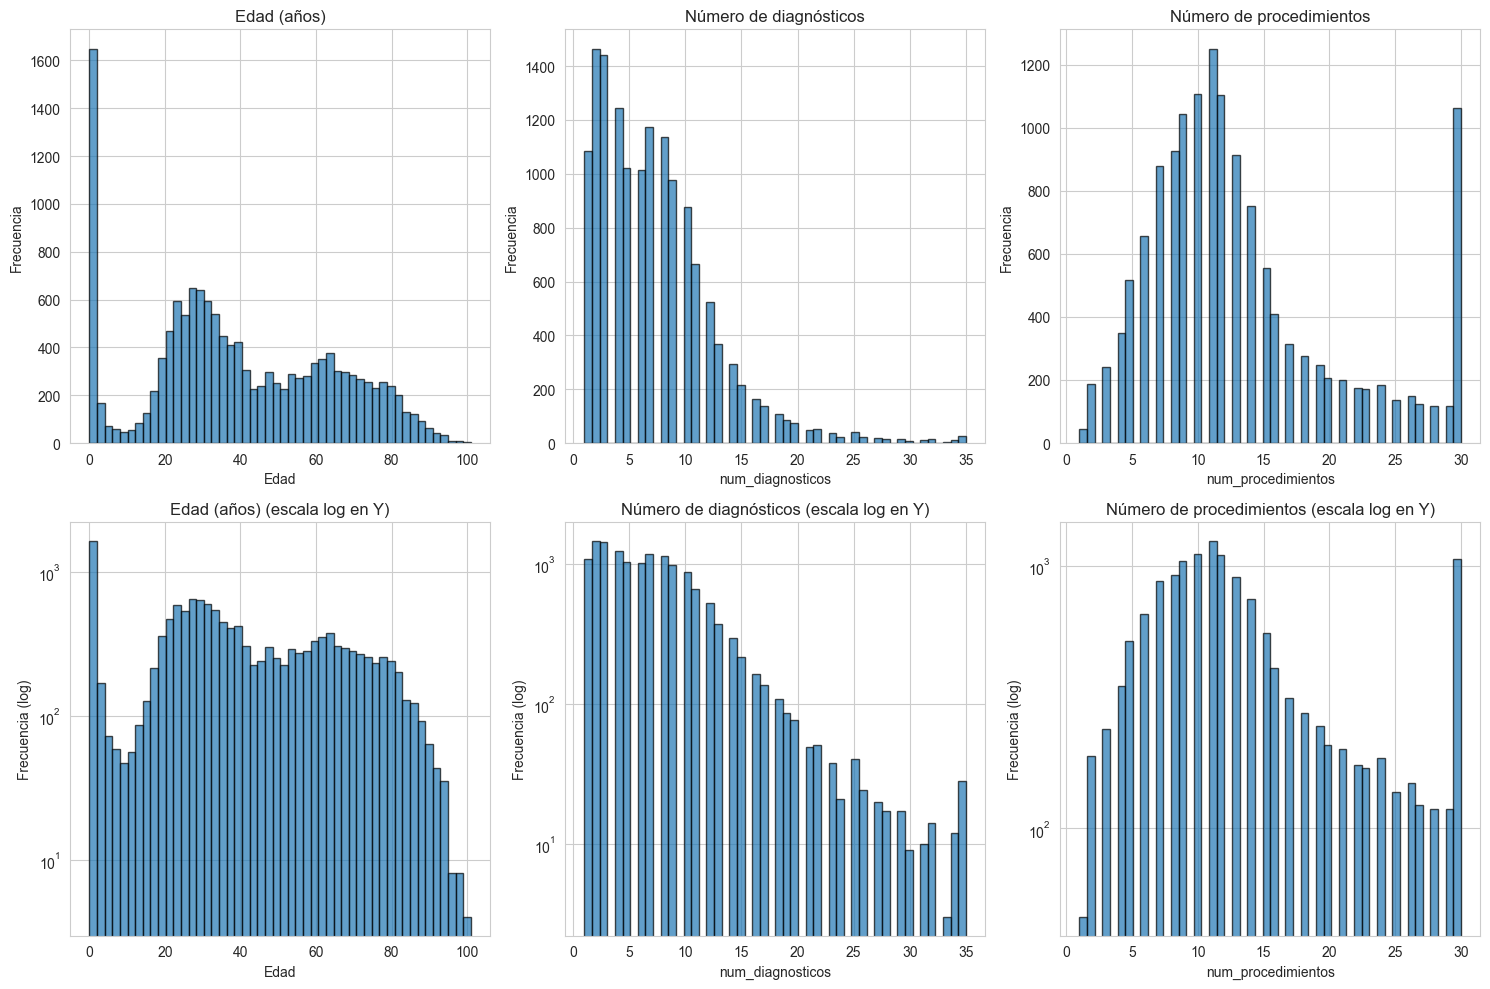

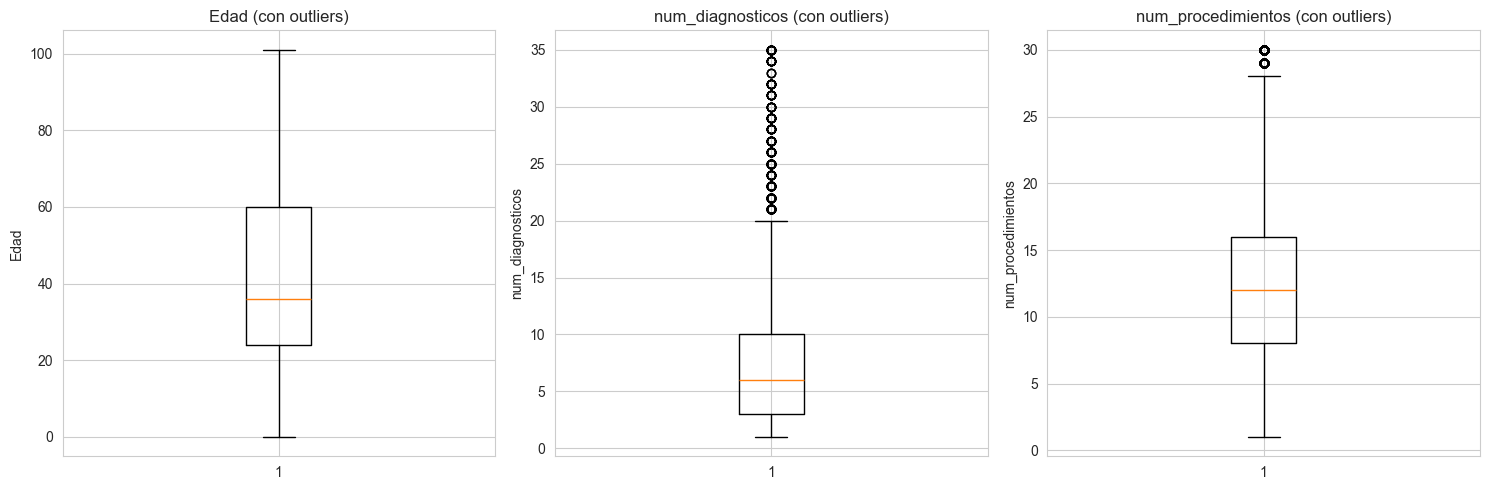


--- Transformación log (para modelos) ---
Se añadieron columnas 'log_diagnosticos' y 'log_procedimientos'
Estadísticas de las variables transformadas:
       log_diagnosticos  log_procedimientos
count      14416.000000        14416.000000
mean           1.916409            2.533852
std            0.635522            0.518999
min            0.693147            0.693147
25%            1.386294            2.197225
50%            1.945910            2.564949
75%            2.397895            2.833213
max            3.583519            3.433987

Correlación entre variables (sin eliminar outliers):
                        Edad  num_diagnosticos  num_procedimientos
Edad                1.000000          0.379051            0.403432
num_diagnosticos    0.379051          1.000000            0.626285
num_procedimientos  0.403432          0.626285            1.000000

Dataset limpio guardado en 'dataset_elpino_clean_no_outlier_removal.csv'


In [2]:
# ==================================================
# 1. Importación de librerías
# ==================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, mstats

# Configuración
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ==================================================
# 2. Carga del dataset
# ==================================================
df = pd.read_csv('dataset_elpino.csv', sep=';', na_values='-', low_memory=False)

# ==================================================
# 3. Limpieza inicial (sin eliminar outliers de diag/proc)
# ==================================================
# Eliminar duplicados exactos
df = df.drop_duplicates()

# Convertir edad a numérica y eliminar solo el outlier extremo (>114 años)
df['Edad'] = pd.to_numeric(df['Edad en años'], errors='coerce')
df = df[~((df['Edad'] > 114) | (df['Edad'] < 0))]  # eliminar edad imposible (>114)

# Convertir sexo a categórica
df['Sexo'] = df['Sexo (Desc)'].astype('category')

# Contar diagnósticos y procedimientos (sin eliminar outliers)
diag_cols = [col for col in df.columns if col.startswith('Diag')]
proc_cols = [col for col in df.columns if col.startswith('Proced')]
df['num_diagnosticos'] = df[diag_cols].notnull().sum(axis=1)
df['num_procedimientos'] = df[proc_cols].notnull().sum(axis=1)

print("Dimensiones después de limpieza básica:", df.shape)
print("Outliers en edad eliminados: solo valores >114 años")
print(f"Rango de diagnósticos: {df['num_diagnosticos'].min()} - {df['num_diagnosticos'].max()}")
print(f"Rango de procedimientos: {df['num_procedimientos'].min()} - {df['num_procedimientos'].max()}")

# ==================================================
# 4. Estadísticas descriptivas (con outliers incluidos)
# ==================================================
print("\n--- Estadísticas descriptivas (con outliers) ---")
for var in ['Edad', 'num_diagnosticos', 'num_procedimientos']:
    datos = df[var].dropna()
    print(f"\n{var}:")
    print(f"  Media: {datos.mean():.2f}")
    print(f"  Mediana: {datos.median():.2f}")
    print(f"  Desv. estándar: {datos.std():.2f}")
    print(f"  Percentil 95: {datos.quantile(0.95):.2f}")
    print(f"  Máximo: {datos.max()}")

# ==================================================
# 5. Comparación por género (sin eliminar outliers)
# ==================================================
print("\n--- Comparación por género (con outliers) ---")
print(df['Sexo'].value_counts())
for var in ['Edad', 'num_diagnosticos', 'num_procedimientos']:
    print(f"\n{var} por género:")
    print(df.groupby('Sexo')[var].describe())

# ==================================================
# 6. Visualizaciones con manejo de outliers
# ==================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Histogramas con escala logarítmica en Y para comprimir colas
variables = ['Edad', 'num_diagnosticos', 'num_procedimientos']
titles = ['Edad (años)', 'Número de diagnósticos', 'Número de procedimientos']
for i, (var, title) in enumerate(zip(variables, titles)):
    ax = axes[0, i]
    ax.hist(df[var].dropna(), bins=50, edgecolor='black', alpha=0.7, log=False)
    ax.set_title(title)
    ax.set_xlabel(var)
    ax.set_ylabel('Frecuencia')
    
    # Segundo histograma con escala log en Y
    ax2 = axes[1, i]
    ax2.hist(df[var].dropna(), bins=50, edgecolor='black', alpha=0.7, log=True)
    ax2.set_title(f'{title} (escala log en Y)')
    ax2.set_xlabel(var)
    ax2.set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.show()

# Boxplots con outliers visibles
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, var in enumerate(variables):
    axes[i].boxplot(df[var].dropna(), vert=True, showfliers=True)
    axes[i].set_title(f'{var} (con outliers)')
    axes[i].set_ylabel(var)
plt.tight_layout()
plt.show()

# ==================================================
# 7. Transformación sugerida para modelos (log)
# ==================================================
df['log_diagnosticos'] = np.log1p(df['num_diagnosticos'])
df['log_procedimientos'] = np.log1p(df['num_procedimientos'])

print("\n--- Transformación log (para modelos) ---")
print("Se añadieron columnas 'log_diagnosticos' y 'log_procedimientos'")
print("Estadísticas de las variables transformadas:")
print(df[['log_diagnosticos', 'log_procedimientos']].describe())

# ==================================================
# 8. Análisis de correlación (opcional)
# ==================================================
corr = df[['Edad', 'num_diagnosticos', 'num_procedimientos']].corr()
print("\nCorrelación entre variables (sin eliminar outliers):")
print(corr)

# ==================================================
# 9. Guardar dataset limpio (sin eliminar outliers de diag/proc)
# ==================================================
df.to_csv('dataset_elpino_clean_no_outlier_removal.csv', index=False)
print("\nDataset limpio guardado en 'dataset_elpino_clean_no_outlier_removal.csv'")